In [25]:
library(tidyverse)
library(fastDummies)
library(broom)
library(glmnet)
library(rpart)
library(rpart.plot)
library(randomForest)

In [2]:
adult_raw <- read_csv("/kaggle/input/datasets/ivancobarrubias/adult-dataset/adult_dataset.csv")

Rows: 48842 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (9): workclass, education, marital-status, occupation, relationship, rac...
dbl (6): age, fnlwgt, education-num, capital-gain, capital-loss, hours-per-week

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Part 1

#### Import:

In [3]:
adult_raw <- as_tibble(adult_raw)
glimpse(adult_raw)

Rows: 48,842
Columns: 15
$ age              <dbl> 39, 50, 38, 53, 28, 37, 49, 52, 31, 42, 37, 30, 23, 3…
$ workclass        <chr> "State-gov", "Self-emp-not-inc", "Private", "Private"…
$ fnlwgt           <dbl> 77516, 83311, 215646, 234721, 338409, 284582, 160187,…
$ education        <chr> "Bachelors", "Bachelors", "HS-grad", "11th", "Bachelo…
$ `education-num`  <dbl> 13, 13, 9, 7, 13, 14, 5, 9, 14, 13, 10, 13, 13, 12, 1…
$ `marital-status` <chr> "Never-married", "Married-civ-spouse", "Divorced", "M…
$ occupation       <chr> "Adm-clerical", "Exec-managerial", "Handlers-cleaners…
$ relationship     <chr> "Not-in-family", "Husband", "Not-in-family", "Husband…
$ race             <chr> "White", "White", "White", "Black", "Black", "White",…
$ sex              <chr> "Male", "Male", "Male", "Male", "Female", "Female", "…
$ `capital-gain`   <dbl> 2174, 0, 0, 0, 0, 0, 0, 0, 14084, 5178, 0, 0, 0, 0, 0…
$ `capital-loss`   <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ `hours-per-we

#### Tidy & Explore:

In [4]:
adult_raw <- adult_raw %>% 
    filter(across(everything(), ~ . != "?")) %>%
    glimpse(
    )


Warning message:
“Using `across()` in `filter()` was deprecated in dplyr 1.0.8.
ℹ Please use `if_any()` or `if_all()` instead.”


Rows: 45,222
Columns: 15
$ age              <dbl> 39, 50, 38, 53, 28, 37, 49, 52, 31, 42, 37, 30, 23, 3…
$ workclass        <chr> "State-gov", "Self-emp-not-inc", "Private", "Private"…
$ fnlwgt           <dbl> 77516, 83311, 215646, 234721, 338409, 284582, 160187,…
$ education        <chr> "Bachelors", "Bachelors", "HS-grad", "11th", "Bachelo…
$ `education-num`  <dbl> 13, 13, 9, 7, 13, 14, 5, 9, 14, 13, 10, 13, 13, 12, 4…
$ `marital-status` <chr> "Never-married", "Married-civ-spouse", "Divorced", "M…
$ occupation       <chr> "Adm-clerical", "Exec-managerial", "Handlers-cleaners…
$ relationship     <chr> "Not-in-family", "Husband", "Not-in-family", "Husband…
$ race             <chr> "White", "White", "White", "Black", "Black", "White",…
$ sex              <chr> "Male", "Male", "Male", "Male", "Female", "Female", "…
$ `capital-gain`   <dbl> 2174, 0, 0, 0, 0, 0, 0, 0, 14084, 5178, 0, 0, 0, 0, 0…
$ `capital-loss`   <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ `hours-per-we

# Part 2

#### Logistic Regression

Logistic Regression Model:

In [5]:
adult_model_data <- adult_raw %>%
  rename_with(~ str_replace_all(., "-", "_")) %>%
  mutate(across(c(workclass, occupation, sex, race, marital_status), as.factor)) %>%
  mutate(income_c = ifelse(income == ">50K", 1, 0))

logit_model <- glm(
  income_c ~ age + workclass + education_num + occupation + 
             hours_per_week + capital_gain + capital_loss + 
             sex + race + marital_status,
  data = adult_model_data,
  family = "binomial"
)

summary(logit_model)



Call:
glm(formula = income_c ~ age + workclass + education_num + occupation + 
    hours_per_week + capital_gain + capital_loss + sex + race + 
    marital_status, family = "binomial", data = adult_model_data)

Coefficients:
                                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)                         -6.872e+00  2.394e-01 -28.703  < 2e-16 ***
age                                  1.996e-02  1.352e-03  14.764  < 2e-16 ***
workclassLocal-gov                  -4.728e-01  8.931e-02  -5.293 1.20e-07 ***
workclassPrivate                    -3.522e-01  7.421e-02  -4.747 2.07e-06 ***
workclassSelf-emp-inc               -3.627e-01  9.466e-02  -3.831 0.000127 ***
workclassSelf-emp-not-inc           -7.173e-01  8.748e-02  -8.200 2.40e-16 ***
workclassState-gov                  -6.195e-01  9.916e-02  -6.248 4.16e-10 ***
workclassWithout-pay                -1.189e+01  1.026e+02  -0.116 0.907708    
education_num                        2.090e-01  7.603e-03  27.4

Significant Predictors:

In [6]:
model_results <- tidy(logit_model)

significant_vars <- model_results %>%
  filter(p.value < 0.05) %>%
  pull(term)

print("--- Significant Predictors ---")
print(significant_vars)

[1] "--- Significant Predictors ---"
 [1] "(Intercept)"                      "age"                             
 [3] "workclassLocal-gov"               "workclassPrivate"                
 [5] "workclassSelf-emp-inc"            "workclassSelf-emp-not-inc"       
 [7] "workclassState-gov"               "education_num"                   
 [9] "occupationExec-managerial"        "occupationFarming-fishing"       
[11] "occupationHandlers-cleaners"      "occupationMachine-op-inspct"     
[13] "occupationOther-service"          "occupationPriv-house-serv"       
[15] "occupationProf-specialty"         "occupationProtective-serv"       
[17] "occupationSales"                  "occupationTech-support"          
[19] "hours_per_week"                   "capital_gain"                    
[21] "capital_loss"                     "sexMale"                         
[23] "raceWhite"                        "marital_statusMarried-AF-spouse" 
[25] "marital_statusMarried-civ-spouse" "marital_statusNever-ma

Compute classification accuracy using a 0.5 threshold:

In [7]:
predicted_probs <- predict(logit_model, type = "response")
predicted_classes <- ifelse(predicted_probs > 0.5, 1, 0)
accuracy <- mean(predicted_classes == adult_model_data$income_c, na.rm = TRUE)

print(paste("Classification Accuracy:", round(accuracy * 100, 2), "%"))

[1] "Classification Accuracy: 84.53 %"


# Part 3

In [8]:
adult_hd <- dummy_cols(
  .data = adult_raw,
  select_columns = c("workclass", "occupation", "sex", "race", "marital-status"),
  remove_first_dummy = TRUE,      # Crucial: prevents perfect multicollinearity
  remove_selected_columns = TRUE  # Drops the original text columns so it's all numeric
)

# Now check the structure
glimpse(adult_hd)

Rows: 45,222
Columns: 40
$ age                                    <dbl> 39, 50, 38, 53, 28, 37, 49, 52,…
$ fnlwgt                                 <dbl> 77516, 83311, 215646, 234721, 3…
$ education                              <chr> "Bachelors", "Bachelors", "HS-g…
$ `education-num`                        <dbl> 13, 13, 9, 7, 13, 14, 5, 9, 14,…
$ relationship                           <chr> "Not-in-family", "Husband", "No…
$ `capital-gain`                         <dbl> 2174, 0, 0, 0, 0, 0, 0, 0, 1408…
$ `capital-loss`                         <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ `hours-per-week`                       <dbl> 40, 13, 40, 40, 40, 40, 16, 45,…
$ `native-country`                       <chr> "United-States", "United-States…
$ income                                 <chr> "<=50K", "<=50K", "<=50K", "<=5…
$ `workclass_Local-gov`                  <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ workclass_Private                      <int> 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1…
$ `workclass_Se

In [9]:
summary(adult_hd)

      age            fnlwgt         education         education-num  
 Min.   :17.00   Min.   :  13492   Length:45222       Min.   : 1.00  
 1st Qu.:28.00   1st Qu.: 117388   Class :character   1st Qu.: 9.00  
 Median :37.00   Median : 178316   Mode  :character   Median :10.00  
 Mean   :38.55   Mean   : 189735                      Mean   :10.12  
 3rd Qu.:47.00   3rd Qu.: 237926                      3rd Qu.:13.00  
 Max.   :90.00   Max.   :1490400                      Max.   :16.00  
 relationship        capital-gain    capital-loss     hours-per-week 
 Length:45222       Min.   :    0   Min.   :   0.00   Min.   : 1.00  
 Class :character   1st Qu.:    0   1st Qu.:   0.00   1st Qu.:40.00  
 Mode  :character   Median :    0   Median :   0.00   Median :40.00  
                    Mean   : 1101   Mean   :  88.59   Mean   :40.94  
                    3rd Qu.:    0   3rd Qu.:   0.00   3rd Qu.:45.00  
                    Max.   :99999   Max.   :4356.00   Max.   :99.00  
 native-country     

In [10]:
adult_hd_clean <- adult_hd %>%
  rename_with(~ str_replace_all(., "-", "_")) %>%
  mutate(income_c = ifelse(income == ">50K", 1, 0)) %>%
  select(-income, -education)


#### Report the number of observations (n) and predictors (p). 

In [11]:
n <- nrow(adult_hd_clean)
p <- ncol(adult_hd_clean) - 1  

print(paste("Number of observations (n):", n))
print(paste("Number of predictors (p):", p))


[1] "Number of observations (n): 45222"
[1] "Number of predictors (p): 38"


#### Explain why this dataset can now be considered high-dimensional.

It is considered high-dimensional because after applying one-hot encoding, the number of columns multiplied into several predictors relative to the original dataset.

#### Fit a standard logistic regression model using adult_hd


In [12]:
logit_hd <- glm(income_c ~ ., data = adult_hd_clean, family = "binomial")
summary(logit_hd)


Call:
glm(formula = income_c ~ ., family = "binomial", data = adult_hd_clean)

Coefficients:
                                           Estimate Std. Error z value Pr(>|z|)
(Intercept)                              -6.973e+00  6.294e-01 -11.080  < 2e-16
age                                       1.938e-02  1.377e-03  14.081  < 2e-16
fnlwgt                                    4.289e-07  1.430e-07   3.000 0.002698
education_num                             2.024e-01  7.706e-03  26.260  < 2e-16
relationshipNot-in-family                 6.950e-01  2.423e-01   2.869 0.004124
relationshipOther-relative               -2.588e-01  2.174e-01  -1.190 0.233891
relationshipOwn-child                    -6.109e-01  2.445e-01  -2.499 0.012455
relationshipUnmarried                     5.354e-01  2.556e-01   2.094 0.036220
relationshipWife                          1.112e+00  8.752e-02  12.710  < 2e-16
capital_gain                              2.832e-05  2.061e-06  13.741  < 2e-16
capital_loss              

#### Describe any issues encountered

Multicollinearity - In high dimensions, certain combinations of dummy variables perfectly predict one another. The math breaks down, and the model has to drop columns (assigning them NA) to function.

Unstable Coefficients - For some of the more specific, rare dummy variables, you will see incredibly high standard errors. This means the model is uncertain about the true effect of that variable, making the coefficient untrustworthy.

Overfitting - Because the model now has so many ultra-specific predictors, it starts memorizing the statistical "noise" of this specific training data instead of learning broad, generalizable rules. If tested on new data, its accuracy would likely drop.

# Part 4

In [13]:
y <- adult_hd_clean$income_c

# 2. Create the predictor matrix, dropping the target AND keeping ONLY numbers
x <- adult_hd_clean %>% 
  select(-income_c) %>%         # Drop the target
  select(where(is.numeric)) %>% 
  as.matrix()

#### Ridge regression model:

In [14]:
cv_ridge <- cv.glmnet(x, y, alpha = 0, family = "binomial")
optimal_lambda_ridge <- cv_ridge$lambda.min

print(paste("Optimal Ridge Lambda:", round(optimal_lambda_ridge, 4)))

[1] "Optimal Ridge Lambda: 0.0129"


#### Lasso regression model

In [15]:
cv_lasso <- cv.glmnet(x, y, alpha = 1, family = "binomial")
optimal_lambda_lasso <- cv_lasso$lambda.min

print(paste("Optimal Lasso Lambda:", round(optimal_lambda_lasso, 4)))

[1] "Optimal Lasso Lambda: 3e-04"


#### Identify which variables are retained (non-zero coefficients) in the Lasso model. 

In [16]:
lasso_coefs <- coef(cv_lasso, s = "lambda.min")
lasso_coefs_mat <- as.matrix(lasso_coefs)
retained_vars <- rownames(lasso_coefs_mat)[lasso_coefs_mat[, 1] != 0]

print(paste("Lasso retained", length(retained_vars), "variables."))
print(retained_vars)

[1] "Lasso retained 34 variables."
 [1] "(Intercept)"                       "age"                              
 [3] "fnlwgt"                            "education_num"                    
 [5] "capital_gain"                      "capital_loss"                     
 [7] "hours_per_week"                    "workclass_Local_gov"              
 [9] "workclass_Private"                 "workclass_Self_emp_inc"           
[11] "workclass_Self_emp_not_inc"        "workclass_State_gov"              
[13] "workclass_Without_pay"             "occupation_Armed_Forces"          
[15] "occupation_Craft_repair"           "occupation_Exec_managerial"       
[17] "occupation_Farming_fishing"        "occupation_Handlers_cleaners"     
[19] "occupation_Machine_op_inspct"      "occupation_Other_service"         
[21] "occupation_Priv_house_serv"        "occupation_Prof_specialty"        
[23] "occupation_Protective_serv"        "occupation_Sales"                 
[25] "occupation_Tech_support"           

#### How do they address multicollinearity?

- Ridge Regression addresses this by "shrinking" the coefficients of highly correlated variables closer to zero without ever actually reaching zero. If two dummy variables are perfectly correlated, Ridge will divide the coefficient penalty evenly between them, stabilizing the math so the model does not crash.

- Lasso Regression addresses this by acting as a harsh judge. If it sees multiple highly correlated variables, it will typically pick the single best one to keep and shrink the coefficients of the redundant variables to exactly zero, effectively removing them from the model entirely.

#### How do they affect model complexity?

- Ridge Regression does not affect this. It simply reduces the weight of other predictors to prevent overfitting.

- Lasso Regression drastically affects this. It forces coefficients to exactly zero, selecting only the important predictors. This allows an easier interpretation of the model and is less prone to overfitting.

# Part 5

#### Growing Trees

In [17]:
tree_data <- adult_raw %>%
  rename_with(~ str_replace_all(., "-", "_")) %>%
  select(-native_country) %>% 
  mutate(across(where(is.character), as.factor))

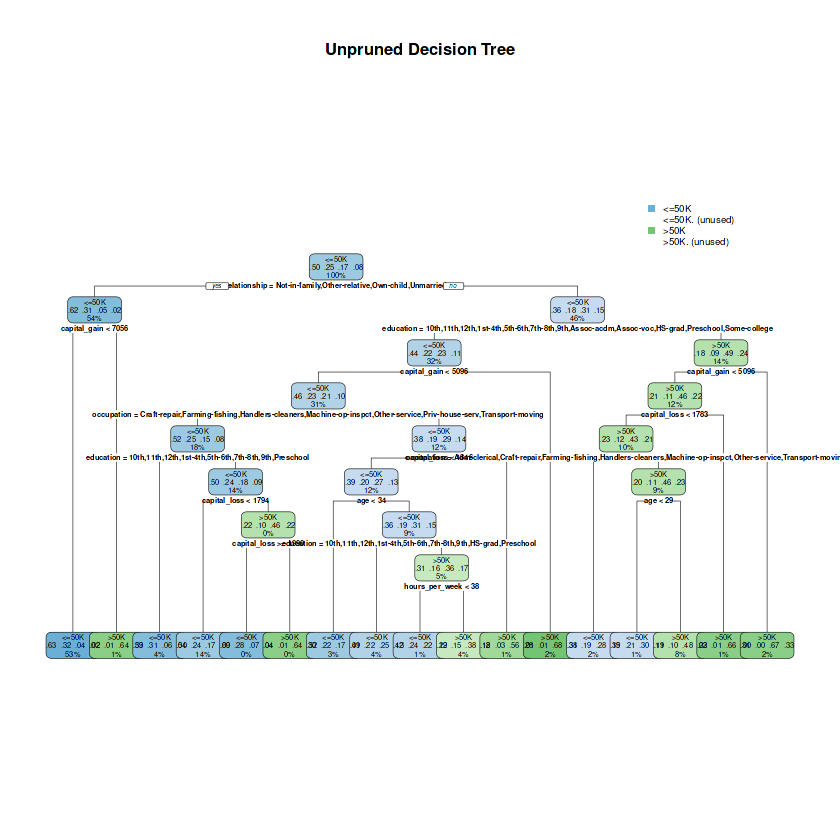

In [20]:
unpruned_tree <- rpart(
  income ~ ., 
  data = tree_data, 
  method = "class", 
  control = rpart.control(cp = 0.001) 
)
rpart.plot(unpruned_tree, main = "Unpruned Decision Tree", tweak = 1.2)

#### Tree Pruning 

[1] "Optimal CP found via Cross-Validation: 0.001"


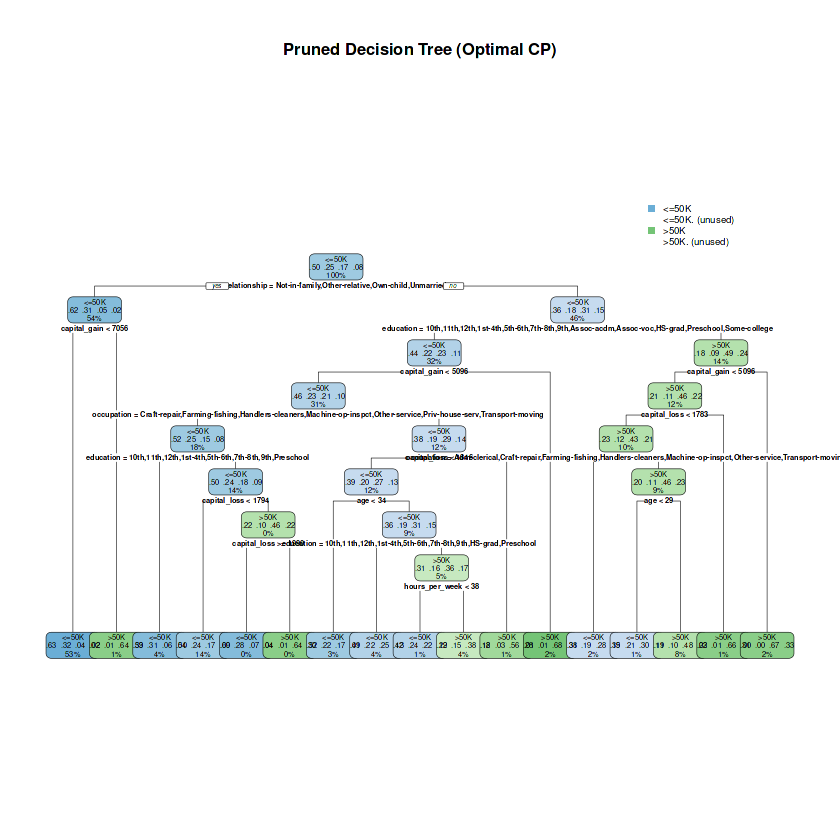

In [22]:
optimal_cp <- unpruned_tree$cptable[which.min(unpruned_tree$cptable[,"xerror"]), "CP"]
print(paste("Optimal CP found via Cross-Validation:", optimal_cp))
pruned_tree <- prune(unpruned_tree, cp = optimal_cp)
rpart.plot(pruned_tree, main = "Pruned Decision Tree (Optimal CP)", tweak = 1.2)

The unprunned tree was slightly overfitting. The pruned tree sacrifices a tiny bit of training accuracy to create a simpler, more generalized model that will perform much better on real-world, unseen dat

#### Interpretation

Looking at the bottom of the tree, the model shows that the most significant predictors happen to be relationship, marital status, capital gain and education.

# Part 6

#### Implement bagging (bootstrap aggregation)

In [30]:
num_predictors <- ncol(tree_data) - 1

bagged_model <- randomForest(
  income ~ ., 
  data = tree_data, 
  mtry = num_predictors,
  ntree = 100,
  importance = TRUE
)

#### Compare performance with a single tree

In [31]:
pred_bagged <- predict(bagged_model, tree_data)
acc_bagged <- mean(pred_bagged == tree_data$income, na.rm = TRUE)

print(paste("Accuracy of Bagged Trees:", round(acc_bagged * 100, 2), "%"))

[1] "Accuracy of Bagged Trees: 99.94 %"


#### Explain why bagging improves model performance

A single decision tree is notorious for having high variance, which makes it highly sensitive to the specific data it was trained on and is highly prone to overfitting.
Bagging (Bootstrap Aggregation) improves performance by taking hundreds of random samples (with replacement) from the dataset, growing a full decision tree for every single sample, and then having all the trees "vote" on the final prediction. By averaging the results of hundreds of different trees, bagging drastically reduces the variance and smooths out the overfitting (the "noise"), resulting in a much more stable, robust, and accurate model.